In [11]:
import pandas as pd
import numpy as np
import hashlib
from collections import Counter
import matplotlib.pyplot as plt

from lifelines import CoxPHFitter
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

# Load incident data

In [12]:
df_incident = pd.read_csv('../../Data/incidence_db.csv', index_col=0)
results_GB_orig = pd.read_parquet('../../Results/wo-used-diag-vars_all-subjects.parquet')

# Define death and end date, and event


## I dont consider alive participant without f_date anda death_date

### All subjects

In [13]:
matched = df_incident.dropna(subset=['uid']).merge(
    results_GB_orig.dropna(subset=['uid']), 
    on="uid", 
    how="inner", 
    suffixes=("_inc", "_gb")
)

matched["date"] = pd.to_datetime(matched["date"], errors="coerce")
matched["death_date"] = pd.to_datetime(matched["death_date"], errors="coerce")
matched["f_date"] = pd.to_datetime(matched["f_date"], errors="coerce")


matched["event"] = matched["death_date"].notna().astype(int)

# End date:
# - if died -> death_date
# - if not died -> f_date (last evaluation)
matched["end_date"] = matched["death_date"].fillna(matched["f_date"])

# (Optional, in case any end_date is empty)
matched["end_date"] = matched["end_date"].fillna(matched["date"].max())

# Time in years
matched["time_years"] = (matched["end_date"] - matched["date"]).dt.days / 365.25

# (Optional) mark invalid times as NaN
matched.loc[matched["time_years"] < 0, "time_years"] = np.nan
matched.loc[matched["time_years"] > 5.5, "time_years"] = np.nan

In [14]:
def forest_plot_gap(cph_unadj, cph_adj,
          color_unadj="#2196F3", color_adj="#E53935",
          gap_var="GAP_z", save_path=None):

  def extract_gap(cph):
    out = cph.summary[["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]].copy()
    out.columns = ["HR", "CI_low", "CI_high", "p_value"]
    return out.loc[gap_var]

  row_u = extract_gap(cph_unadj)
  row_a = extract_gap(cph_adj)

  models   = ["Unadjusted", "Adjusted"]
  rows    = [row_u, row_a]
  colors   = [color_unadj, color_adj]
  markers   = ["s", "o"]     # <-- square / circle
  y_positions = [1, 0]

  fig, ax = plt.subplots(figsize=(6, 2.5))

  for model, row, color, marker, y in zip(models, rows, colors, markers, y_positions):
    ax.plot([row["CI_low"], row["CI_high"]], [y, y],
        color=color, linewidth=2.0, zorder=2)
    ax.plot(row["HR"], y, marker=marker, color=color,
        ms=9, zorder=3, linestyle="None")

    p = row["p_value"]
    p_str = "p<0.001" if p < 0.001 else f"p={p:.3f}"
    ax.text(row["CI_high"] + 0.01, y,
        f"HR={row['HR']:.3f} [{row['CI_low']:.3f}–{row['CI_high']:.3f}] {p_str}",
        va="center", fontsize=8, color=color)

  ax.axvline(1.0, color="gray", linestyle="--", linewidth=0.8, zorder=1)
  ax.set_yticks(y_positions)
  ax.set_yticklabels(models, fontsize=9)
  ax.set_xlabel("Hazard Ratio (95% CI)", fontsize=9)
  ax.set_title(f"Forest Plot — {gap_var}", fontsize=10, fontweight="bold")
  ax.set_ylim(-0.5, 1.5)
  ax.set_xlim(0.95, 1.7)
  ax.spines["top"].set_visible(False)
  ax.spines["right"].set_visible(False)
  plt.tight_layout()

  if save_path:
    plt.savefig(save_path, format="pdf", bbox_inches="tight", dpi=300)
    print(f" Saved: {save_path}")

  plt.show()

#### Cox model

In [15]:
from lifelines import CoxPHFitter


df_surv = matched[['time_years', 'event', 'GAP_corrected']].dropna()

cph = CoxPHFitter().fit(df_surv, duration_col='time_years', event_col='event')

out = cph.summary.loc[['GAP_corrected'], ['exp(coef)', 'exp(coef) lower 95%', 'exp(coef) upper 95%', 'p']]
out = out.rename(columns={
  'exp(coef)': 'HR',
  'exp(coef) lower 95%': 'CI95_low',
  'exp(coef) upper 95%': 'CI95_high',
  'p': 'p_value'
})
out


,HR,CI95_low,CI95_high,p_value
covariate,,,,
GAP_corrected,1.163519,1.14594,1.181368,1.145121e-84


In [16]:
covars = ['Age', 'Male', 'Education']


In [17]:
from lifelines import CoxPHFitter

def compact_all(cph):
  out = cph.summary.loc[:, ["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]].copy()
  out.columns = ["HR", "CI95_low", "CI95_high", "p_value"]
  return out.sort_values("p_value")




In [18]:
from IPython.display import display
matched["Male"] = (matched["Sex_1F_2M"] == 2).astype(int)
matched["GAP_z"] = (matched["GAP_corrected"] - matched["GAP_corrected"].mean()) / matched["GAP_corrected"].std()

# Unadjusted (by 1 SD)
df_z_unadj = matched[["time_years", "event", "GAP_z"]].dropna()
cph_z_unadj = CoxPHFitter()
cph_z_unadj.fit(df_z_unadj, duration_col="time_years", event_col="event")
print("--- Cox GAP_z (UNADJUSTED) ---")
display(compact_all(cph_z_unadj))

# Adjusted (by 1 SD) using Male dummy
needed_cols_z = ["time_years", "event", "GAP_z"] + covars
df_z_adj = matched[needed_cols_z].dropna()
cph_z_adj = CoxPHFitter()
cph_z_adj.fit(df_z_adj, duration_col="time_years", event_col="event")
print("\n\n--- Cox GAP_z (ADJUSTED) ---")
display(compact_all(cph_z_adj))


--- Cox GAP_z (UNADJUSTED) ---


,HR,CI95_low,CI95_high,p_value
covariate,,,,
GAP_z,1.572579,1.502618,1.645798,1.145121e-84




--- Cox GAP_z (ADJUSTED) ---


,HR,CI95_low,CI95_high,p_value
covariate,,,,
Age,1.084854,1.077416,1.092344,4.393706e-119
GAP_z,1.439065,1.375752,1.505292,1.275140e-56
Male,1.512063,1.349768,1.693872,9.510994e-13
Education,0.998685,0.949978,1.049889,9.588537e-01


 Saved: ../../Figures/Model-B_forest-plot_All-subjects.pdf


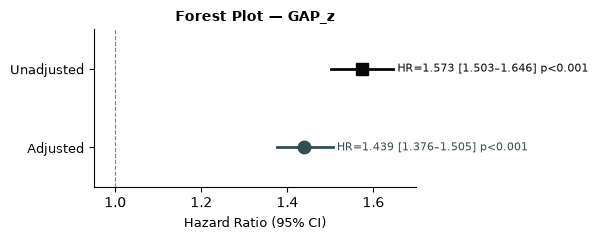

In [19]:
forest_plot_gap(cph_z_unadj, cph_z_adj,
        color_unadj="#090608",
        color_adj="#334E50",
        save_path="../../Figures/Model-B_forest-plot_All-subjects.pdf")

#### Meta analysis urban rural

In [ ]:
import numpy as np
import pandas as pd
from lifelines import CoxPHFitter

meta_results = []

matched_for_meta = matched.copy()

matched_for_meta['Countries_inc'] = matched_for_meta['Countries_inc'].replace({
  'Peru (urban)': 'Peru',
  'Peru (rural)': 'Peru',
  'Mexico (rural)': 'Mexico',
  'Mexico (urban)': 'Mexico',
  'DR': 'Dominican R.'
})

for country in matched_for_meta['Countries_inc'].dropna().unique():
  
  c_matched = matched_for_meta[matched_for_meta['Countries_inc'] == country].copy()
  
  c_matched["Male"] = (c_matched["Sex_1F_2M"] == 2).astype(int)
  
  # Standardize within country
  sd_gap = c_matched["GAP_corrected"].std()
  
  if pd.isna(sd_gap) or sd_gap == 0:
    print(f"Skipping {country}: GAP_corrected std is 0 or NaN")
    continue
  
  c_matched["GAP_z"] = (matched["GAP_corrected"] - c_matched["GAP_corrected"].mean()) / c_matched["GAP_corrected"].std()


  # Unadjusted Cox model
  df_z_unadj = c_matched[["time_years", "event", "GAP_z"]].dropna()
  
  n = len(df_z_unadj)
  n_events = df_z_unadj["event"].sum()
  
  # Skip countries with too little information
  if n < 10 or n_events < 3:
    print(f"Skipping {country}: too few observations or events (n={n}, events={n_events})")
    continue
  
  try:
    cph_z_unadj = CoxPHFitter()
    cph_z_unadj.fit(df_z_unadj, duration_col="time_years", event_col="event")
    
    row = cph_z_unadj.summary.loc["GAP_z"]
    
    meta_results.append({
      "country": country,
      "n": n,
      "events": n_events,
      "logHR": row["coef"],
      "HR": row["exp(coef)"],
      "SE": row["se(coef)"],
      "lower_CI": row["exp(coef) lower 95%"],
      "upper_CI": row["exp(coef) upper 95%"],
      "p_value": row["p"]
    })
    
    print(f"Done: {country}")
    
  except Exception as e:
    print(f"Error in {country}: {e}")

meta_df = pd.DataFrame(meta_results)
meta_df.to_csv('../../MetaAnalysis/Data/Model-B-meta-table.csv')
display(meta_df)

Done: Cuba


Done: Dominican R.
Done: Peru
Done: Venezuela
Done: Mexico
Done: Puerto Rico


,country,n,events,logHR,HR,SE,lower_CI,upper_CI,p_value
0,Cuba,1955,437,0.463160,1.589088,0.038312,1.474134,1.713007,1.204017e-33
1,Dominican R.,1503,342,0.329017,1.389602,0.049004,1.262346,1.529687,1.891988e-11
2,Peru,1530,92,0.429789,1.536933,0.088746,1.291560,1.828923,1.279335e-06
3,Venezuela,1508,127,0.415914,1.515756,0.073204,1.313161,1.749608,1.334639e-08
4,Mexico,1604,111,0.509462,1.664395,0.074944,1.437024,1.927742,1.061567e-11
5,Puerto Rico,1427,196,0.536525,1.710054,0.061495,1.515880,1.929099,2.669888e-18


#### Survive curve

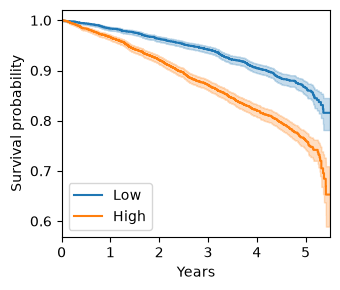

In [21]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt


matched["GAP_group"] = np.where(matched["GAP_corrected"] <= 0, "Low", "High")
matched["GAP_group_bin"] = np.where(matched["GAP_corrected"] <= 0, 0, 1)
matched["GAP_group"].value_counts(dropna=False)


kmf = KaplanMeierFitter()
plt.figure(figsize=(3.5,3.0))

for g in ["Low", "High"]:
  mask = matched["GAP_group"] == g
  df_g = matched.loc[mask, ["time_years", "event"]].dropna()
  kmf.fit(df_g["time_years"], df_g["event"], label=g)
  kmf.plot_survival_function(ci_show=True)

plt.xlabel("Years")
plt.ylabel("Survival probability")
#plt.title("Kaplan–Meier survival by GAP_corrected (≤0 vs >0)")
plt.tight_layout()
plt.xlim([0,5.5])


plt.savefig("../../Figures/Model-B_kaplan_meier_All-subjects.pdf", format="pdf", bbox_inches="tight", dpi=300)

plt.show()


#### Log rank

In [22]:
from lifelines.statistics import logrank_test

df_low = matched.loc[matched["GAP_group"]=="Low", ["time_years","event"]].dropna()
df_high = matched.loc[matched["GAP_group"]=="High", ["time_years","event"]].dropna()

lr = logrank_test(
  df_low["time_years"], df_high["time_years"],
  event_observed_A=df_low["event"],
  event_observed_B=df_high["event"]
)

print(f"Log-rank p = {lr.p_value:.3g}")


Log-rank p = 7.71e-35


### Only HC

In [23]:
matched = df_incident.dropna(subset=['uid']).merge(
    results_GB_orig.dropna(subset=['uid']), 
    on="uid", 
    how="inner", 
    suffixes=("_inc", "_gb")
)
matched = matched[matched.anydem == 0].reset_index(drop = True)


matched["date"] = pd.to_datetime(matched["date"], errors="coerce")
matched["death_date"] = pd.to_datetime(matched["death_date"], errors="coerce")
matched["f_date"] = pd.to_datetime(matched["f_date"], errors="coerce")


matched["event"] = matched["death_date"].notna().astype(int)

# End date:
# - if died -> death_date
# - if not died -> f_date (last evaluation)
matched["end_date"] = matched["death_date"].fillna(matched["f_date"])

# (Optional, in case any end_date is empty)
matched["end_date"] = matched["end_date"].fillna(matched["date"].max())

# Time in years
matched["time_years"] = (matched["end_date"] - matched["date"]).dt.days / 365.25

# (Optional) mark invalid times as NaN
matched.loc[matched["time_years"] < 0, "time_years"] = np.nan
matched.loc[matched["time_years"] > 5.5, "time_years"] = np.nan

In [24]:
matched.shape

(9158, 45)

#### Cox model

In [25]:
from lifelines import CoxPHFitter


df_surv = matched[['time_years', 'event', 'GAP_corrected']].dropna()

cph = CoxPHFitter().fit(df_surv, duration_col='time_years', event_col='event')

out = cph.summary.loc[['GAP_corrected'], ['exp(coef)', 'exp(coef) lower 95%', 'exp(coef) upper 95%', 'p']]
out = out.rename(columns={
  'exp(coef)': 'HR',
  'exp(coef) lower 95%': 'CI95_low',
  'exp(coef) upper 95%': 'CI95_high',
  'p': 'p_value'
})
out


,HR,CI95_low,CI95_high,p_value
covariate,,,,
GAP_corrected,1.13134,1.108769,1.154369,3.461167e-33


In [26]:
from lifelines import CoxPHFitter

matched["Male"] = (matched["Sex_1F_2M"] == 2).astype(int)



matched["GAP_z"] = (matched["GAP_corrected"] - matched["GAP_corrected"].mean()) / matched["GAP_corrected"].std()

# Unadjusted (by 1 SD)
df_z_unadj = matched[["time_years", "event", "GAP_z"]].dropna()
cph_z_unadj = CoxPHFitter()
cph_z_unadj.fit(df_z_unadj, duration_col="time_years", event_col="event")
print("--- Cox GAP_z (UNADJUSTED) ---")
display(compact_all(cph_z_unadj))

# Adjusted (by 1 SD) using Male dummy
needed_cols_z = ["time_years", "event", "GAP_z"] + covars
df_z_adj = matched[needed_cols_z].dropna()
cph_z_adj = CoxPHFitter()
cph_z_adj.fit(df_z_adj, duration_col="time_years", event_col="event")
print("\n\n--- Cox GAP_z (ADJUSTED) ---")
display(compact_all(cph_z_adj))


--- Cox GAP_z (UNADJUSTED) ---


,HR,CI95_low,CI95_high,p_value
covariate,,,,
GAP_z,1.401461,1.326307,1.480873,3.461167e-33




--- Cox GAP_z (ADJUSTED) ---


,HR,CI95_low,CI95_high,p_value
covariate,,,,
Age,1.087221,1.078218,1.096299,1.706837e-86
GAP_z,1.355861,1.285808,1.429731,2.378928e-29
Male,1.535875,1.351474,1.745436,4.852505e-11
Education,0.949820,0.896747,1.006035,7.928027e-02


#### Survive curve

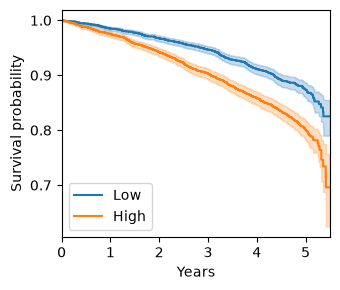

In [27]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt


matched["GAP_group"] = np.where(matched["GAP_corrected"] <= 0, "Low", "High")
matched["GAP_group_bin"] = np.where(matched["GAP_corrected"] <= 0, 0, 1)
matched["GAP_group"].value_counts(dropna=False)


kmf = KaplanMeierFitter()
plt.figure(figsize=(3.5,3.0))

for g in ["Low", "High"]:
  mask = matched["GAP_group"] == g
  df_g = matched.loc[mask, ["time_years", "event"]].dropna()
  kmf.fit(df_g["time_years"], df_g["event"], label=g)
  kmf.plot_survival_function(ci_show=True)

plt.xlabel("Years")
plt.ylabel("Survival probability")
#plt.title("Kaplan–Meier survival by GAP_corrected (≤0 vs >0)")
plt.tight_layout()

plt.xlim([0,5.5])

plt.savefig("../../Figures/Model-B_kaplan_meier_HC-subjects.pdf", format="pdf", bbox_inches="tight", dpi=300)

plt.show()


#### Log rank

In [28]:
from lifelines.statistics import logrank_test

df_low = matched.loc[matched["GAP_group"]=="Low", ["time_years","event"]].dropna()
df_high = matched.loc[matched["GAP_group"]=="High", ["time_years","event"]].dropna()

lr = logrank_test(
  df_low["time_years"], df_high["time_years"],
  event_observed_A=df_low["event"],
  event_observed_B=df_high["event"]
)

print(f"Log-rank p = {lr.p_value:.3g}")


Log-rank p = 1.5e-16


 Saved: ../../Figures/Model-B_forest-plot_HC.pdf


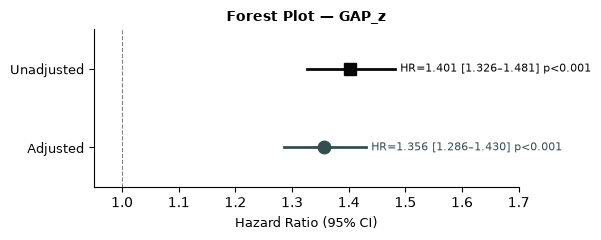

In [29]:
forest_plot_gap(cph_z_unadj, cph_z_adj,
        color_unadj="#090608",
        color_adj="#334E50",
        save_path="../../Figures/Model-B_forest-plot_HC.pdf")

### Only dem

In [30]:
matched = df_incident.dropna(subset=['uid']).merge(
    results_GB_orig.dropna(subset=['uid']), 
    on="uid", 
    how="inner", 
    suffixes=("_inc", "_gb")
)
matched = matched[matched.anydem == 1].reset_index(drop = True)


matched["date"] = pd.to_datetime(matched["date"], errors="coerce")
matched["death_date"] = pd.to_datetime(matched["death_date"], errors="coerce")
matched["f_date"] = pd.to_datetime(matched["f_date"], errors="coerce")


matched["event"] = matched["death_date"].notna().astype(int)

# End date:
# - if died -> death_date
# - if not died -> f_date (last evaluation)
matched["end_date"] = matched["death_date"].fillna(matched["f_date"])

# (Optional, in case any end_date is empty)
matched["end_date"] = matched["end_date"].fillna(matched["date"].max())

# Time in years
matched["time_years"] = (matched["end_date"] - matched["date"]).dt.days / 365.25

# (Optional) mark invalid times as NaN
matched.loc[matched["time_years"] < 0, "time_years"] = np.nan
matched.loc[matched["time_years"] > 4.5, "time_years"] = np.nan

In [31]:
matched.shape

(975, 45)

#### Cox model

In [32]:
from lifelines import CoxPHFitter


df_surv = matched[['time_years', 'event', 'GAP_corrected']].dropna()

cph = CoxPHFitter().fit(df_surv, duration_col='time_years', event_col='event')

out = cph.summary.loc[['GAP_corrected'], ['exp(coef)', 'exp(coef) lower 95%', 'exp(coef) upper 95%', 'p']]
out = out.rename(columns={
  'exp(coef)': 'HR',
  'exp(coef) lower 95%': 'CI95_low',
  'exp(coef) upper 95%': 'CI95_high',
  'p': 'p_value'
})
out


,HR,CI95_low,CI95_high,p_value
covariate,,,,
GAP_corrected,1.098514,1.069618,1.128191,4.904392e-12


In [33]:
from lifelines import CoxPHFitter

matched["Male"] = (matched["Sex_1F_2M"] == 2).astype(int)



matched["GAP_z"] = (matched["GAP_corrected"] - matched["GAP_corrected"].mean()) / matched["GAP_corrected"].std()

# Unadjusted (by 1 SD)
df_z_unadj = matched[["time_years", "event", "GAP_z"]].dropna()
cph_z_unadj = CoxPHFitter()
cph_z_unadj.fit(df_z_unadj, duration_col="time_years", event_col="event")
print("--- Cox GAP_z (UNADJUSTED) ---")
display(compact_all(cph_z_unadj))

# Adjusted (by 1 SD) using Male dummy
needed_cols_z = ["time_years", "event", "GAP_z"] + covars
df_z_adj = matched[needed_cols_z].dropna()
cph_z_adj = CoxPHFitter()
cph_z_adj.fit(df_z_adj, duration_col="time_years", event_col="event")
print("\n\n--- Cox GAP_z (ADJUSTED) ---")
display(compact_all(cph_z_adj))


--- Cox GAP_z (UNADJUSTED) ---


,HR,CI95_low,CI95_high,p_value
covariate,,,,
GAP_z,1.448404,1.303898,1.608925,4.904392e-12




--- Cox GAP_z (ADJUSTED) ---


,HR,CI95_low,CI95_high,p_value
covariate,,,,
GAP_z,1.507931,1.353396,1.680110,9.646505e-14
Age,1.040313,1.025205,1.055643,1.188957e-07
Education,1.219747,1.102706,1.349210,1.136105e-04
Male,1.451185,1.126497,1.869457,3.954821e-03


#### Survive curve

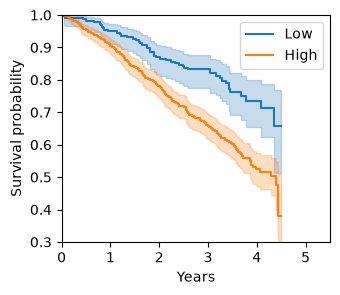

In [34]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt


matched["GAP_group"] = np.where(matched["GAP_corrected"] <= 0, "Low", "High")
matched["GAP_group_bin"] = np.where(matched["GAP_corrected"] <= 0, 0, 1)
matched["GAP_group"].value_counts(dropna=False)


kmf = KaplanMeierFitter()
plt.figure(figsize=(3.5,3.0))

for g in ["Low", "High"]:
  mask = matched["GAP_group"] == g
  df_g = matched.loc[mask, ["time_years", "event"]].dropna()
  kmf.fit(df_g["time_years"], df_g["event"], label=g)
  kmf.plot_survival_function(ci_show=True)

plt.xlabel("Years")
plt.ylabel("Survival probability")
#plt.title("Kaplan–Meier survival by GAP_corrected (≤0 vs >0)")
plt.tight_layout()
plt.xlim([0,5.5])
plt.ylim([0.3, 1])


plt.savefig("../../Figures/Model-B_kaplan_meier_Dem-subjects.pdf", format="pdf", bbox_inches="tight", dpi=300)

plt.show()


#### Log rank

In [35]:
from lifelines.statistics import logrank_test

df_low = matched.loc[matched["GAP_group"]=="Low", ["time_years","event"]].dropna()
df_high = matched.loc[matched["GAP_group"]=="High", ["time_years","event"]].dropna()

lr = logrank_test(
  df_low["time_years"], df_high["time_years"],
  event_observed_A=df_low["event"],
  event_observed_B=df_high["event"]
)

print(f"Log-rank p = {lr.p_value:.3g}")


Log-rank p = 4.11e-06


 Saved: ../../Figures/Model-B_forest-plot_Dementia.pdf


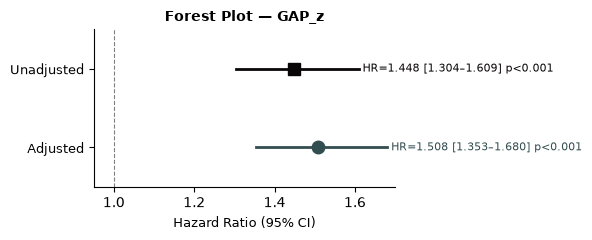

In [36]:
forest_plot_gap(cph_z_unadj, cph_z_adj,
        color_unadj="#090608",
        color_adj="#334E50",
        save_path="../../Figures/Model-B_forest-plot_Dementia.pdf")

# Longitudinal analysis

## Matched BBAGw1 vs BBAGw2

In [37]:
results_GB_incident = pd.read_parquet('../../Results/wo-used-diag-vars_all-subjects-Incidence.parquet')

matched = results_GB_incident.dropna(subset=["uid"]).merge(
    results_GB_orig.dropna(subset=["uid"]), 
    on="uid", 
    how="inner", 
    suffixes=("_w2", "_w1")
)

matched = df_incident[["uid", "death_date", "f_date"]].dropna(subset=["uid"]).merge(
    matched, 
    on="uid", 
    how="inner"
)

In [38]:
matched["date_w1"] = pd.to_datetime(matched["date_w1"], errors="coerce")
matched["death_date"] = pd.to_datetime(matched["death_date"], errors="coerce")
matched["f_date"] = pd.to_datetime(matched["f_date"], errors="coerce")


matched["event"] = matched["death_date"].notna().astype(int)

# End date:
# - if died -> death_date
# - if not died -> f_date (last evaluation)
matched["end_date"] = matched["death_date"].fillna(matched["f_date"])

# (Optional, in case any end_date is empty)
#matched["end_date"] = matched["end_date"].fillna(matched["date"].max())

# Time in years
matched["time_years"] = (matched["end_date"] - matched["date_w1"]).dt.days / 365.25
matched["time_day"] = (matched["end_date"] - matched["date_w1"]).dt.days
# (Optional) mark invalid times as NaN
matched.loc[matched["time_years"] < 0, "time_years"] = np.nan

In [39]:
matched["GAP_corrected_w2_time_c"] = matched["GAP_corrected_w2"] / matched["time_day"]

In [40]:
def plot_pred_vs_true_density(df_final, x , y):
  import numpy as np
  import matplotlib.pyplot as plt
  from scipy.stats import gaussian_kde
  from scipy.stats import linregress

  [y_true_all, y_pred_all] = df_final[x], df_final[y]

  xy = np.vstack([y_true_all, y_pred_all]) 
  density = gaussian_kde(xy)(xy)      

  sizes = 100 * (density / density.max()) 



  scatter = plt.scatter(y_true_all, y_pred_all, c=density, s=sizes, cmap='gray', alpha=0.6)
  #plt.plot([min(y_true_all), max(y_true_all)], [min(y_true_all), max(y_true_all)], 'k--')
  slope, intercept, r_value, p_value, std_err = linregress(df_final[x], df_final[y])
  plt.plot(df_final[x], intercept + slope * df_final[x], color='black')
  plt.xlabel(x)
  plt.ylabel(y)

  r_value1 = np.abs(r_value)
  d_cohen = (2 * r_value1) / np.sqrt(1 - r_value1**2)

  plt.title( f'd-cohen={d_cohen:.2f} \nr={r_value:.2f} p={p_value:.2e}')



  return None

# -----------------------------
# Remove outliers using IQR (per variable)
# -----------------------------
def remove_iqr_outliers(df, cols, k=1.5):
  mask = np.ones(len(df), dtype=bool)
  for c in cols:
    q1 = df[c].quantile(0.25)
    q3 = df[c].quantile(0.75)
    iqr = q3 - q1
    low = q1 - k * iqr
    high = q3 + k * iqr
    mask &= df[c].between(low, high)
  return df.loc[mask]

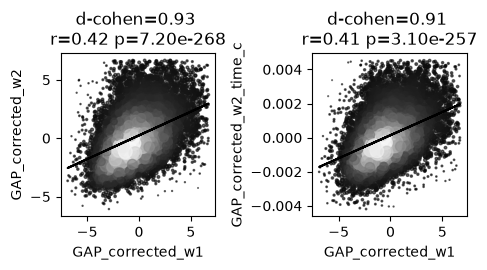

In [41]:
plt.figure(figsize=(5, 2.8))
plt.subplot(1,2,1)

ycol = "GAP_corrected_w2"
xcol = "GAP_corrected_w1"

d = matched[[xcol, ycol]].dropna().copy()

d = remove_iqr_outliers(d, [xcol, ycol], k=1.5)

plot_pred_vs_true_density(d, "GAP_corrected_w1", "GAP_corrected_w2")



ycol = "GAP_corrected_w2_time_c"
xcol = "GAP_corrected_w1"

d = matched[[xcol, ycol]].dropna().copy()

d = remove_iqr_outliers(d, [xcol, ycol], k=1.5)

plt.subplot(1,2,2)
plot_pred_vs_true_density(d, "GAP_corrected_w1", "GAP_corrected_w2_time_c")

plt.tight_layout()

plt.savefig("../../Figures/Model-B_scatterplot-long.pdf", format="pdf", bbox_inches="tight", dpi=300)